
# Blending Ensemble for Classification (ML)
# The objective is to produce a model to predict positive moves (up trend) using the Blending Ensemble technique. The proposed solution should be comprehensive with the detailed model architecture, evaluated with a backtest applied to a trading strategy.


## Step 1 : Importing Libraries and the data

In [1]:
# For data manipulation & visualization of results
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import quantstats as qs

# Machine learning libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# To ignore unwanted warnings
import warnings
%matplotlib inline
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Fetch the 'TSLA' historical price data over 5 years of time
data = yf.download('TSLA', start="2019-01-05", end="2024-01-05")

# Fixing MultiIndex
data.columns = data.columns.get_level_values(0)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2019-01-07,22.330667,22.449333,21.183332,21.448000,113268000
2019-01-08,22.356667,22.934000,21.801332,22.797333,105127500
2019-01-09,22.568666,22.900000,22.098000,22.366667,81493500
2019-01-10,22.997999,23.025999,22.119333,22.293333,90846000
2019-01-11,23.150667,23.227333,22.584667,22.806000,75586500


##   Step 2 : Features Construction

In [3]:
# Features construction
data['Open-Close'] = (data.Open - data.Close)/data.Open
data['High-Low'] = (data.High - data.Low)/data.Low
data['Daily_Returns'] = np.log(data['Close']/data['Close'].shift(1))
data['Past_Returns'] = data['Daily_Returns'].shift(1)
data['ret_5'] = data['Daily_Returns'].rolling(5).mean()
data['std_5'] = data['Daily_Returns'].rolling(5).std()
data['Momentum_15'] = data['Close'] - data['Close'].shift(15)
data['SMA_15'] = data['Close'].rolling(window=15).mean()
data['EMA_15'] = data['Close'].ewm(span=15,min_periods=15).mean()
data['Trend'] = np.where(data['Daily_Returns'] > 0, 1, 0)
data.dropna(inplace=True)
data.head()

Price,Close,High,Low,Open,Volume,Open-Close,High-Low,Daily_Returns,Past_Returns,ret_5,std_5,Momentum_15,SMA_15,EMA_15,Trend
Date,,,,,,,,,,,,,,,
2019-01-29,19.830667,19.903999,19.453333,19.684668,69325500,-0.007417,0.023167,0.003637,-0.002224,-0.000979,0.022599,-2.500000,21.375378,20.691944,1
2019-01-30,20.584667,20.600000,19.899332,20.030001,168754500,-0.027692,0.035211,0.037317,0.003637,0.014212,0.015307,-1.771999,21.257244,20.676990,1
2019-01-31,20.468000,20.770666,19.600000,20.066668,188538000,-0.020000,0.059728,-0.005684,0.037317,0.010368,0.017739,-2.100666,21.117200,20.648270,0
2019-02-01,20.813999,21.073334,20.233334,20.361334,109251000,-0.022232,0.041516,0.016763,-0.005684,0.009962,0.017520,-2.184000,20.971600,20.670765,1
2019-02-04,20.859333,21.020000,20.125334,20.865334,110281500,0.000288,0.044455,0.002176,0.016763,0.010842,0.016853,-2.291334,20.818844,20.696089,1


In [4]:
data = data.drop(['Open', 'High', 'Low', 'Close','Volume'],axis=1)
data.head()

Price,Open-Close,High-Low,Daily_Returns,Past_Returns,ret_5,std_5,Momentum_15,SMA_15,EMA_15,Trend
Date,,,,,,,,,,
2019-01-29,-0.007417,0.023167,0.003637,-0.002224,-0.000979,0.022599,-2.500000,21.375378,20.691944,1
2019-01-30,-0.027692,0.035211,0.037317,0.003637,0.014212,0.015307,-1.771999,21.257244,20.676990,1
2019-01-31,-0.020000,0.059728,-0.005684,0.037317,0.010368,0.017739,-2.100666,21.117200,20.648270,0
2019-02-01,-0.022232,0.041516,0.016763,-0.005684,0.009962,0.017520,-2.184000,20.971600,20.670765,1
2019-02-04,0.000288,0.044455,0.002176,0.016763,0.010842,0.016853,-2.291334,20.818844,20.696089,1


## Step 3 : Exploratory Data Analysis (EDA)

## 3.1 Summary Statistics

In [5]:
data.describe()

Price,Open-Close,High-Low,Daily_Returns,Past_Returns,ret_5,std_5,Momentum_15,SMA_15,EMA_15,Trend
count,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000
mean,-0.000771,0.047945,0.002002,0.002002,0.002032,0.034932,2.758407,171.937291,171.948675,0.532582
std,0.032237,0.027691,0.040709,0.040709,0.018856,0.020131,31.144553,107.239798,106.860458,0.499138
min,-0.157803,0.008483,-0.236518,-0.236518,-0.112585,0.005708,-97.940002,13.030533,13.360949,0.000000
25%,-0.018344,0.029766,-0.017728,-0.017728,-0.008803,0.020953,-9.628326,51.134600,50.208961,0.000000
50%,-0.000699,0.041095,0.002003,0.002003,0.001933,0.030679,1.260665,201.984000,202.463121,1.000000
75%,0.016415,0.056715,0.021976,0.021976,0.012727,0.044797,15.998337,251.888444,250.515245,1.000000
max,0.127897,0.260950,0.181445,0.181445,0.089546,0.150292,138.883331,373.074219,367.871660,1.000000


## 3.2 Correlation Analysis

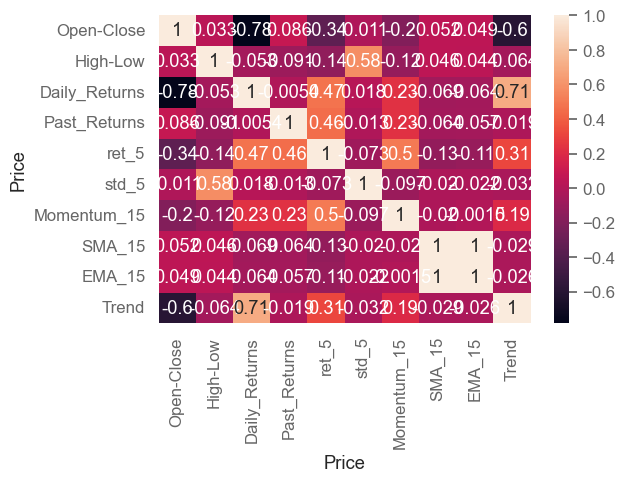

In [6]:
# Plot correlation matrix in heatmap
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(data.corr(), ax=ax, annot=True)
plt.show()

## 3.3  Multicollinearity Analysis
## Detecting Multicollinearity Using a Variance Inflation Factor (VIF):

In [7]:
# Import library for VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(data):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["Features"] = data.columns
    vif["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]

    return(vif)
df = data.iloc[:,:-1]
calc_vif(df)

,Features,VIF
0,Open-Close,2.639151
1,High-Low,5.571827
2,Daily_Returns,3.005669
3,Past_Returns,1.409374
4,ret_5,2.338632
5,std_5,5.302949
6,Momentum_15,1.589110
7,SMA_15,4260.736111
8,EMA_15,4271.837895


### We can see here that the ‘Adj Close’ ,‘SMA_15’ & 'EMA_15' have a very high VIF value, meaning they can be predicted by other features in the dataset. VIF exceeding 5 or 10 indicates high multicollinearity between the features.

## Step 4 & 5 : Features' Transformation based on EDA

## 5.1 Fixing Multicollinearity
### Dropping these highly correlated features will help in bringing down the multicollinearity between other correlated features:

In [8]:
df = data.drop(['High-Low','std_5','SMA_15','EMA_15'],axis=1)
calc_vif(df)

,Features,VIF
0,Open-Close,2.640698
1,Daily_Returns,3.256339
2,Past_Returns,1.396649
3,ret_5,2.133098
4,Momentum_15,1.361254
5,Trend,1.379991


## 5.2 Scatter/Regression Plots:

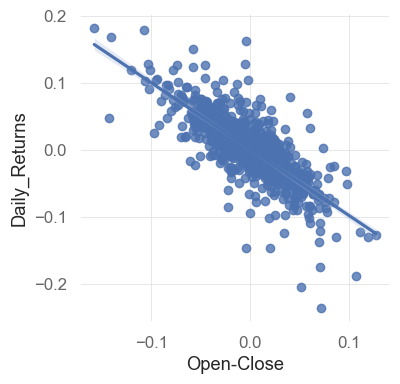

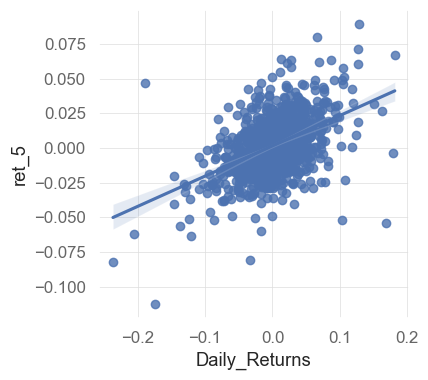

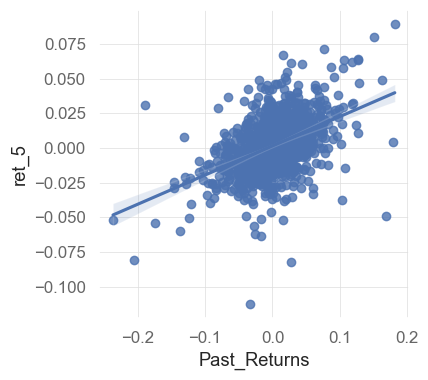

In [9]:
fig1,ax1,= plt.subplots(figsize=(4, 4))
sns.regplot(x = df['Open-Close'], y = df['Daily_Returns'], ax=ax1)
fig2,ax2,= plt.subplots(figsize=(4, 4))
sns.regplot(x = df['Daily_Returns'], y = df['ret_5'], ax=ax2)
fig3,ax3,= plt.subplots(figsize=(4, 4))
sns.regplot(x = df['Past_Returns'], y = df['ret_5'], ax=ax3)
plt.show()

## Step 6: Model Building (Base Models & the Meta Model)

## 6.1 Setting input & target variables

In [10]:
# X is the input variable
X = df[['Open-Close','Daily_Returns','Past_Returns','ret_5']]

# Y is the target or output variable
y = df['Trend']

## 6.2 Generating the Training & Testing Datasets

In [11]:
# Splitiing the X and y into train and test datasets

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the size of the train and test dataset
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(870, 4) (187, 4)
(870,) (187,)


##  6.3 Defining the base models & Evaluation Function

In [13]:
# Define the base models
dt_classifier = DecisionTreeClassifier()
rf_classifier = RandomForestClassifier()
knn_classifier = KNeighborsClassifier()
xgb_classifier = XGBClassifier()

# Define the Evaluation metric Function
def evaluate_model(model, X_val, y_val, X_test, y_test, model_name="Model"):
    """
    Evaluate classification model with standard metrics + confusion matrix plot.
    
    Parameters:
    - model: trained model
    - X_val, y_val: validation data
    - X_test, y_test: test data
    - model_name: string (for labeling outputs)
    
    Returns:
    - dict of metrics
    """

    # Predictions
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # Metrics
    roc_auc = roc_auc_score(y_val, y_val_pred)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    class_report = classification_report(y_val, y_val_pred)
    accuracy = accuracy_score(y_test, y_test_pred) * 100.0

    # Print results
    print(f"\n===== {model_name} Evaluation =====")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print(f"\nConfusion Matrix:\n{conf_matrix}")
    print(f"\nClassification Report:\n{class_report}")
    print(f"Accuracy (Test): {accuracy:.2f}%")

    # Plot confusion matrix
    plt.figure(figsize=(4, 4))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cbar=False,
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # Return metrics (useful for comparison tables later)
    return {
        "model": model_name,
        "roc_auc": roc_auc,
        "accuracy": accuracy,
        "confusion_matrix": conf_matrix,
        "classification_report": class_report
    }


## 6.3.1 Base Model 1: Decision Tree Classifier


===== Decision Tree Classifier Evaluation =====
ROC AUC Score: 1.0000

Confusion Matrix:
[[92  0]
 [ 0 94]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        92
           1       1.00      1.00      1.00        94

    accuracy                           1.00       186
   macro avg       1.00      1.00      1.00       186
weighted avg       1.00      1.00      1.00       186

Accuracy (Test): 99.47%


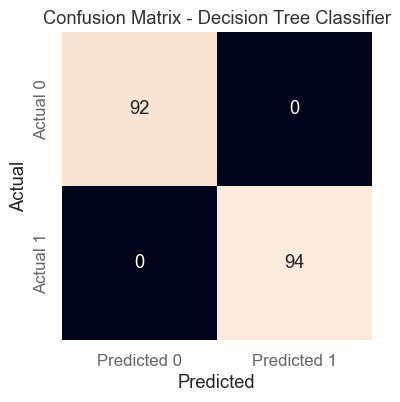

{'model': 'Decision Tree Classifier',
 'roc_auc': 1.0,
 'accuracy': 99.46524064171123,
 'confusion_matrix': array([[92,  0],
        [ 0, 94]]),
 'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        92\n           1       1.00      1.00      1.00        94\n\n    accuracy                           1.00       186\n   macro avg       1.00      1.00      1.00       186\nweighted avg       1.00      1.00      1.00       186\n'}

In [14]:
from sklearn.metrics import roc_auc_score, confusion_matrix , classification_report , accuracy_score

Model_1_dtClassifier = DecisionTreeClassifier()
Model_1_dtClassifier.fit(X_train, y_train)
evaluate_model(Model_1_dtClassifier, X_val, y_val, X_test, y_test, model_name="Decision Tree Classifier")

## 6.3.2 Base Model 2: Random Forest Classifier


===== Random Forest Classifier Evaluation =====
ROC AUC Score: 1.0000

Confusion Matrix:
[[92  0]
 [ 0 94]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        92
           1       1.00      1.00      1.00        94

    accuracy                           1.00       186
   macro avg       1.00      1.00      1.00       186
weighted avg       1.00      1.00      1.00       186

Accuracy (Test): 99.47%


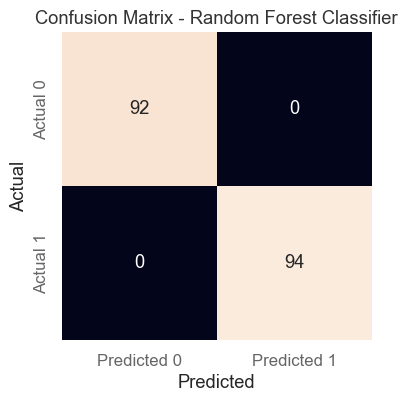

{'model': 'Random Forest Classifier',
 'roc_auc': 1.0,
 'accuracy': 99.46524064171123,
 'confusion_matrix': array([[92,  0],
        [ 0, 94]]),
 'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        92\n           1       1.00      1.00      1.00        94\n\n    accuracy                           1.00       186\n   macro avg       1.00      1.00      1.00       186\nweighted avg       1.00      1.00      1.00       186\n'}

In [15]:
Model_2_rfc = RandomForestClassifier()
Model_2_rfc.fit(X_train, y_train)
evaluate_model(Model_2_rfc, X_val, y_val, X_test, y_test, model_name="Random Forest Classifier")

## 6.3.3 Base Model 3: KNN Classifier


===== KNN Classifier Evaluation =====
ROC AUC Score: 0.9460

Confusion Matrix:
[[85  7]
 [ 3 91]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        92
           1       0.93      0.97      0.95        94

    accuracy                           0.95       186
   macro avg       0.95      0.95      0.95       186
weighted avg       0.95      0.95      0.95       186

Accuracy (Test): 93.58%


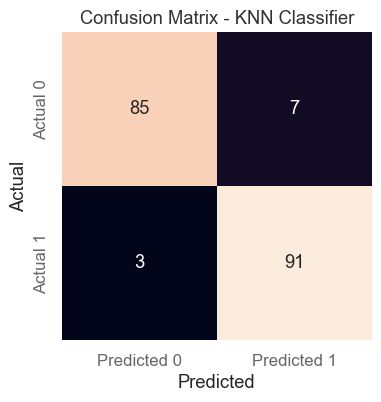

{'model': 'KNN Classifier',
 'roc_auc': 0.9459990749306197,
 'accuracy': 93.58288770053476,
 'confusion_matrix': array([[85,  7],
        [ 3, 91]]),
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.97      0.92      0.94        92\n           1       0.93      0.97      0.95        94\n\n    accuracy                           0.95       186\n   macro avg       0.95      0.95      0.95       186\nweighted avg       0.95      0.95      0.95       186\n'}

In [16]:
Model_3_knn = KNeighborsClassifier()
Model_3_knn.fit(X_train, y_train)
evaluate_model(Model_3_knn, X_val, y_val, X_test, y_test, model_name="KNN Classifier")


## 6.3.4 Base Model 4: XGBoost Classifier


===== XGBoost Classifier Evaluation =====
ROC AUC Score: 1.0000

Confusion Matrix:
[[92  0]
 [ 0 94]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        92
           1       1.00      1.00      1.00        94

    accuracy                           1.00       186
   macro avg       1.00      1.00      1.00       186
weighted avg       1.00      1.00      1.00       186

Accuracy (Test): 100.00%


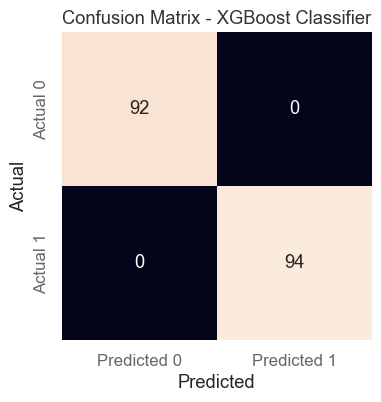

{'model': 'XGBoost Classifier',
 'roc_auc': 1.0,
 'accuracy': 100.0,
 'confusion_matrix': array([[92,  0],
        [ 0, 94]]),
 'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        92\n           1       1.00      1.00      1.00        94\n\n    accuracy                           1.00       186\n   macro avg       1.00      1.00      1.00       186\nweighted avg       1.00      1.00      1.00       186\n'}

In [17]:
Model_4_xgb = XGBClassifier()
Model_4_xgb.fit(X_train, y_train)
evaluate_model(Model_4_xgb, X_val, y_val, X_test, y_test, model_name="XGBoost Classifier")


## 6.4 Optimizing the hyperparameters of each base models

In [18]:

# Define hyperparameter grids for each classifier
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

param_grid_xgb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 0.9, 1.0]
}

# Perform Grid Search for each classifier
grid_search_dt = GridSearchCV(dt_classifier, param_grid_dt, cv=5)
grid_search_rf = GridSearchCV(rf_classifier, param_grid_rf, cv=5)
grid_search_knn = GridSearchCV(knn_classifier, param_grid_knn, cv=5)
grid_search_xgb = GridSearchCV(xgb_classifier, param_grid_xgb, cv=5)

# Fit the models
grid_search_dt.fit(X_train, y_train)
grid_search_rf.fit(X_train, y_train)
grid_search_knn.fit(X_train, y_train)
grid_search_xgb.fit(X_train, y_train)

# Print the best hyperparameters for each classifier
print("Best Hyperparameters for Decision Tree:", grid_search_dt.best_params_)
print("Best Hyperparameters for Random Forest:", grid_search_rf.best_params_)
print("Best Hyperparameters for K Neighbors:", grid_search_knn.best_params_)
print("Best Hyperparameters for XGBoost:", grid_search_xgb.best_params_)

Best Hyperparameters for Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Hyperparameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Hyperparameters for K Neighbors: {'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Best Hyperparameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}


## 6.5 Stacking the optimized base models into the Meta Model with the Logistic Regression as the final estimator

In [19]:
# Create a stacked classifier with Logistic Regression as the final estimator

stacked_classifier = StackingClassifier(
    estimators=[
        ('decision_tree', grid_search_dt.best_estimator_),
        ('random_forest', grid_search_rf.best_estimator_),
        ('k_neighbors', grid_search_knn.best_estimator_),
        ('xgboost', grid_search_xgb.best_estimator_)
    ],
    final_estimator=LogisticRegression()
)

# Fit the stacked classifier
stacked_classifier.fit(X_train, y_train)



,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('decision_tree', ...), ('random_forest', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=

## Step 7: Stacked Classifier Model Evaluation
## 7.1 Metrics Computation:


===== Stacked Ensemble Classifier Evaluation =====
ROC AUC Score: 1.0000

Confusion Matrix:
[[92  0]
 [ 0 94]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        92
           1       1.00      1.00      1.00        94

    accuracy                           1.00       186
   macro avg       1.00      1.00      1.00       186
weighted avg       1.00      1.00      1.00       186

Accuracy (Test): 99.47%


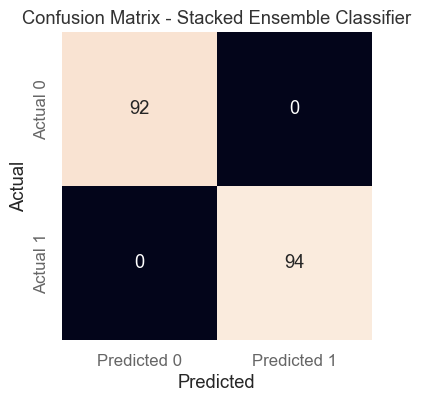

{'model': 'Stacked Ensemble Classifier',
 'roc_auc': 1.0,
 'accuracy': 99.46524064171123,
 'confusion_matrix': array([[92,  0],
        [ 0, 94]]),
 'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        92\n           1       1.00      1.00      1.00        94\n\n    accuracy                           1.00       186\n   macro avg       1.00      1.00      1.00       186\nweighted avg       1.00      1.00      1.00       186\n'}

In [20]:
# Metrics Computation

Stacked_Model = stacked_classifier
evaluate_model(Stacked_Model, X_val, y_val, X_test, y_test, model_name="Stacked Ensemble Classifier")


## 7.3 Plotting the ROC Curve:

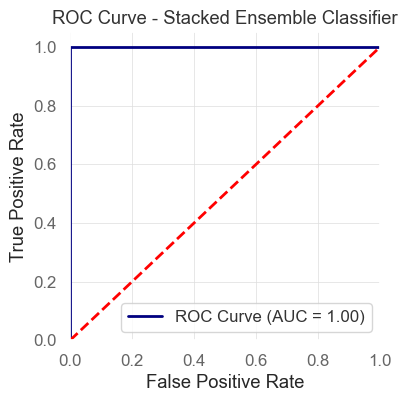

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(
    y_val,
    stacked_classifier.predict_proba(X_val)[:, 1]
)

# Compute AUC
roc_auc = roc_auc_score(
    y_val,
    stacked_classifier.predict_proba(X_val)[:, 1]
)

# Plot
plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='navy', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacked Ensemble Classifier')
plt.legend(loc='lower right')
plt.show()

## 7.4 Application to trading strategy:
### 7.4.1 Calculating Strategy Returns

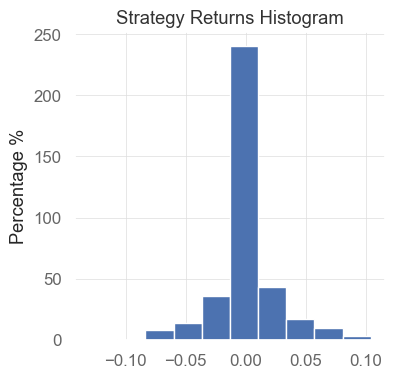

In [22]:
# Now,We will visualize the strategy returns in the histogram plot.

df['Strategy_Returns'] = df['Daily_Returns'].shift(-1) * stacked_classifier.predict(X)

# As '870' is size of trainig dataset we want to evaluate the model on the testing dataset

df.Strategy_Returns.iloc[870:].hist(figsize=(4,4)) 
plt.title('Strategy Returns Histogram')
plt.ylabel('Percentage %')
plt.show()

### 7.4.2 Strategy Performance Metrics


Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Strategy
-------------------------  ----------
Start Period               2022-07-13
End Period                 2024-01-03
Risk-Free Rate             0.0%
Time in Market             53.0%

Cumulative Return          47.59%
CAGR﹪                     30.17%

Sharpe                     0.86
Prob. Sharpe Ratio         85.04%
Smart Sharpe               0.83
Sortino                    1.28
Smart Sortino              1.23
Sortino/√2                 0.9
Smart Sortino/√2           0.87
Omega                      1.22

Max Drawdown               -44.78%
Max DD Date                2023-01-04
Max DD Period Start        2022-08-04
Max DD Period End          2023-06-08
Longest DD Days            309
Volatility (ann.)          40.34%
Calmar                     0.67
Skew                       0.08
Kurtosis                   4.8
Ulcer Performance I

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2022-08-04,2023-01-04,2023-06-08,309,-44.784065,-43.107495
2,2023-07-18,2023-10-27,2023-12-12,148,-20.109085,-18.214409
3,2023-06-20,2023-06-22,2023-06-29,10,-8.517866,-6.339322
4,2023-12-15,2023-12-27,2024-01-03,20,-6.606392,-5.274998
5,2023-07-05,2023-07-05,2023-07-11,7,-2.125228,-1.330353


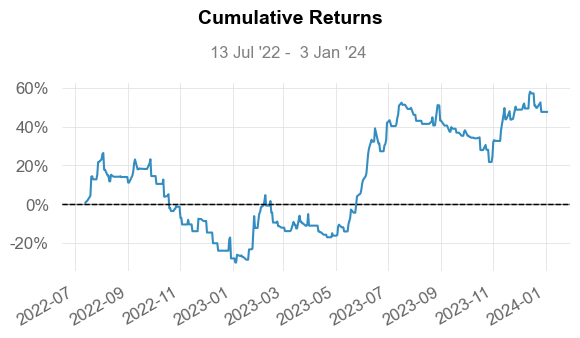

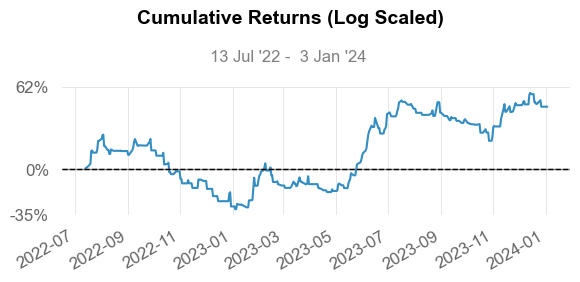

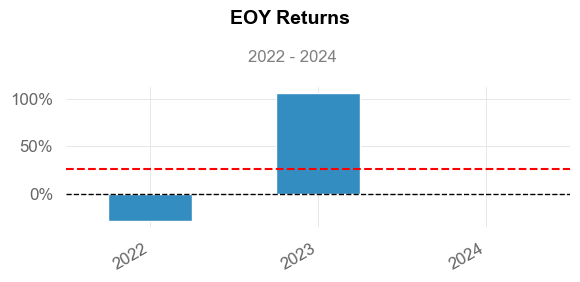

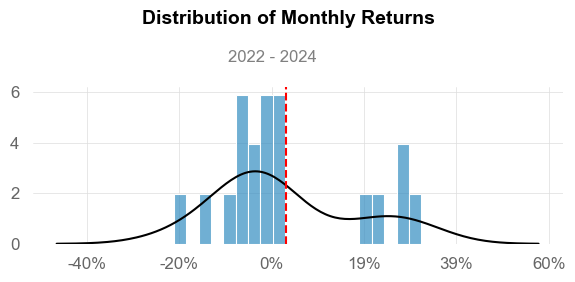

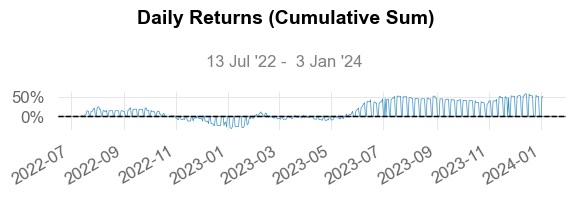

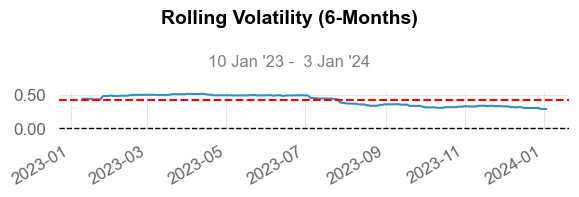

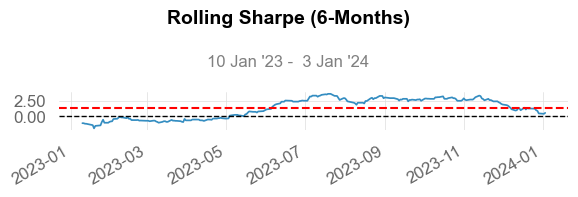

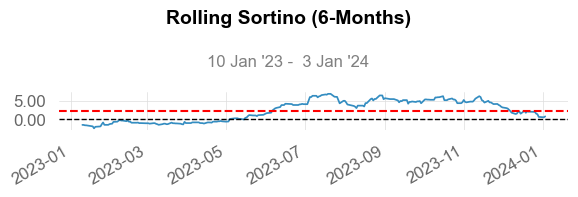

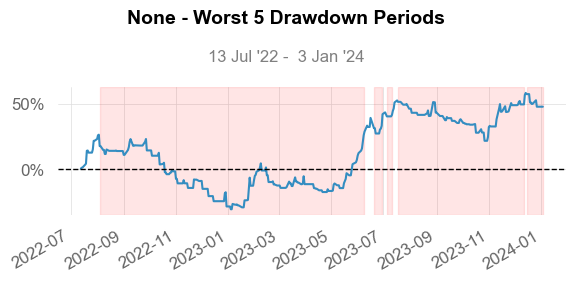

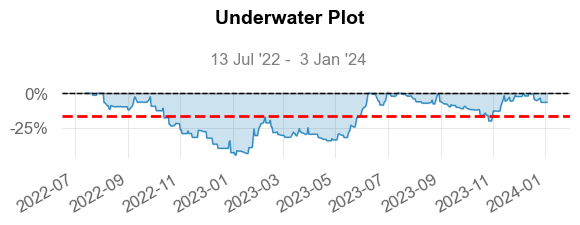

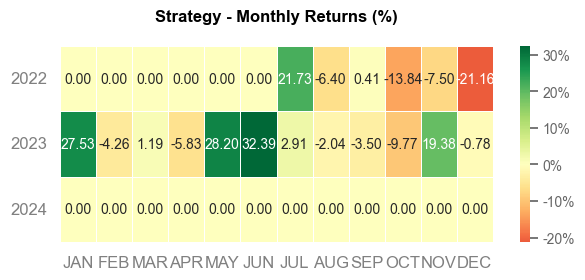

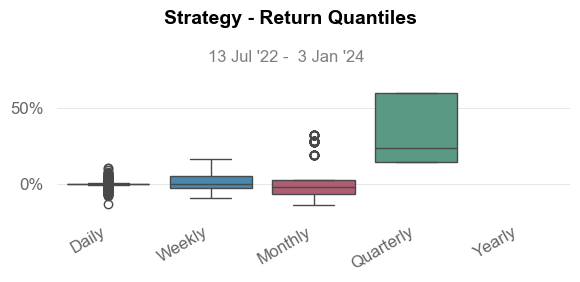

None


In [23]:
# Print a summary report of various performance metrics

qs.extend_pandas()

# As '870' is size of the trainig dataset we want to evaluate the model on the testing dataset
returns = df.Strategy_Returns.iloc[870:] 

print(qs.reports.full(returns,figsize=(6,6)))